model comparison - cancer dataset
----------------------------------------
naive bayes -> cv accuracy: 0.928
svm -> cv accuracy: 0.974
knn -> cv accuracy: 0.965
logistic regression -> cv accuracy: 0.981


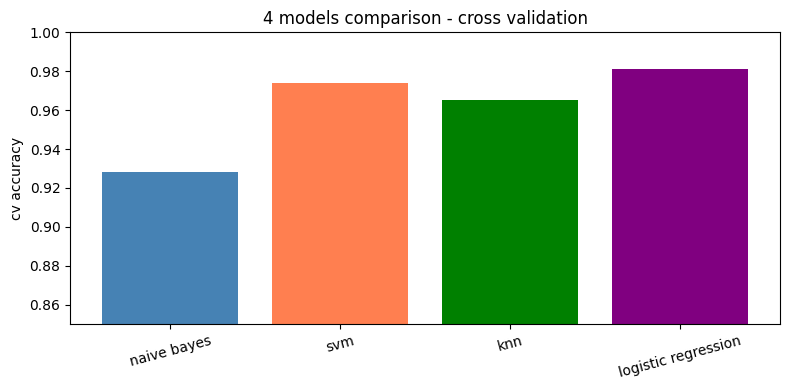

In [2]:
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

cancer = load_breast_cancer()
x = cancer.data
y = cancer.target

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

x_train, x_test, y_train, y_test = train_test_split(
    x_scaled, y, test_size=0.2, random_state=42
)

models = {
    "naive bayes":         GaussianNB(),
    "svm":                 SVC(random_state=42),
    "knn":                 KNeighborsClassifier(),
    "logistic regression": LogisticRegression(max_iter=1000)
}

print("model comparison - cancer dataset")
print("-" * 40)

cv_scores = {}
for name, model in models.items():
    cv = cross_val_score(model, x_scaled, y, cv=5)
    cv_scores[name] = round(np.mean(cv), 3)
    print(name, "-> cv accuracy:", cv_scores[name])

plt.figure(figsize=(8, 4))
plt.bar(cv_scores.keys(), cv_scores.values(),
        color=["steelblue", "coral", "green", "purple"])
plt.title("4 models comparison - cross validation")
plt.ylabel("cv accuracy")
plt.ylim(0.85, 1.0)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()